# 01 - Data download and cleaning

**Part 1 of the assignment.** Downloads the raw *Appliances Energy Prediction* dataset from the UCI repository, checks missing values, and resamples the native 10-minute readings to hourly means so the forecast horizon (24 hours) is a manageable 24 steps instead of 144.

All the logic lives in `src/appliance_energy/data.py` - this notebook only calls it and inspects the result, so the same cleaning code is reused by the main pipeline (`scripts/run_pipeline.py`).

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


## Download the raw 10-minute data

In [2]:
raw = D.download_raw_data()
print(raw.shape)
raw.head()

Using cached raw data at /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/raw/energydata_complete.csv
(19735, 28)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Missing values

The original dataset is known to be essentially complete (no missing readings), which we confirm directly rather than assume.

In [3]:
D.report_missing_values(raw)

,n_missing,pct_missing
Appliances,0,0.0
lights,0,0.0
rv1,0,0.0
Tdewpoint,0,0.0
Visibility,0,0.0
Windspeed,0,0.0
RH_out,0,0.0
Press_mm_hg,0,0.0
T_out,0,0.0
RH_9,0,0.0


## Cleaning

`clean_raw_data` coerces every column to numeric, drops the two random noise columns (`rv1`, `rv2`) the original dataset authors included as a sanity check plus the redundant `NSM`/`WeekStatus`/`Day_of_week` columns (all directly derivable from the timestamp index), and drops any row with a missing target.

In [4]:
clean = D.clean_raw_data(raw)
print('Columns dropped:', set(raw.columns) - set(clean.columns))
clean.shape

Columns dropped: {'rv1', 'rv2'}


(19735, 26)

## Resample to hourly

Binning the 10-minute readings up to hourly means (Part 1 instruction). Small resampling gaps are filled by time-weighted interpolation.

In [5]:
hourly = D.resample_hourly(clean)
print('Hourly shape:', hourly.shape)
print('Date range:', hourly.index.min(), 'to', hourly.index.max())
hourly.to_csv(config.HOURLY_DATA_PATH)
hourly.head()

Hourly shape: (3290, 26)
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667


## Sanity-check plot

A first look at the target variable before any modelling, just to confirm the resampling produced a sensible, gap-free series.

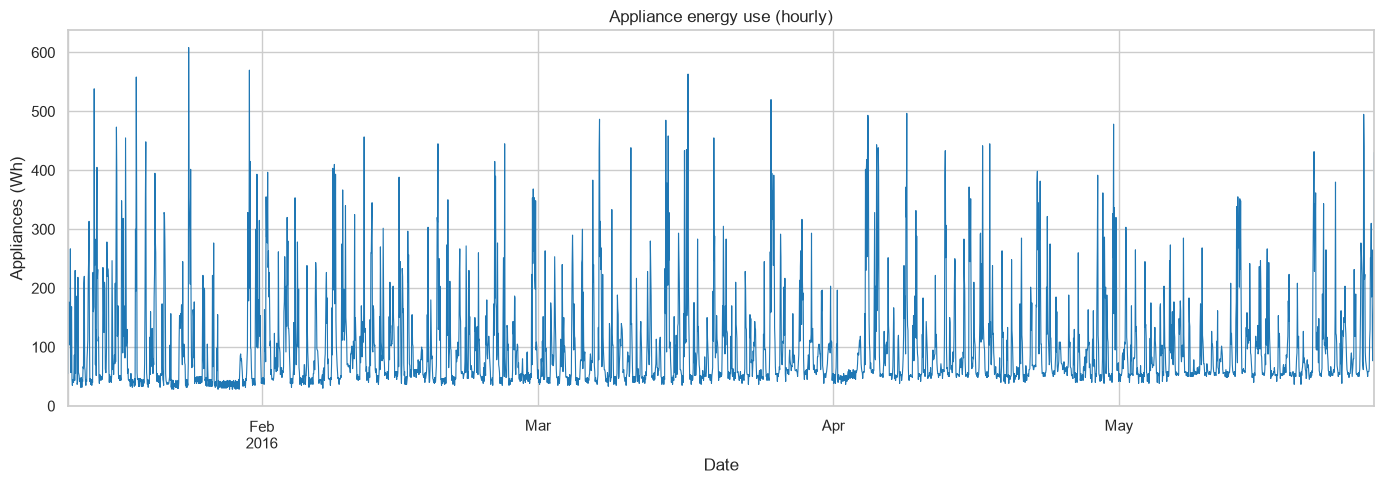

In [6]:
fig = P.plot_full_series(hourly[config.TARGET])
plt.show()

### Notes

- The raw data has essentially no missing values, so cleaning mostly just removes redundant columns rather than imputing gaps.
- Resampling to hourly reduces ~19,735 ten-minute rows to ~3,290 hourly rows spanning roughly 4.5 months (Jan-May 2016), still plenty for both classical (SARIMAX) and ML models while keeping the SARIMA AIC grid search (Part 4) computationally tractable.